# 04 — UL-DD Exploratory Data Analysis

Inspect the raw UL-DD dataset:
- KSS label distribution and class mapping
- Facial Action Unit (FAU) statistics per subject
- Telemetry (CAN) statistics per subject
- Missing-data heatmap (A=no tele, C/F/L=no drowsy)
- Pairwise AU correlation
- Sample time-series windows

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# ── add src/ to path ──────────────────────────────────────────────────────────
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# ── UL-DD paths ───────────────────────────────────────────────────────────────
ULDD_ROOT = Path(r'C:/Users/raka1005/Documents/IISC/UL-DD')
FAU_DIR   = ULDD_ROOT / 'Extracted_Features' / 'Extracted_Features' / 'Extracted_Features'
TELE_DIR  = ULDD_ROOT / 'CSV_Files' / 'CSV_Files' / 'CSV_Files'
LABEL_CSV = ULDD_ROOT / 'Labels.csv'

SUBJECTS  = list('ABCDEFGHIJKLMNOPQRS')
SESSIONS  = ['A', 'D']   # Alert, Drowsy
KSS_LABELS = {**{k: 0 for k in range(1,4)},   # Alert
              **{k: 1 for k in range(4,7)},   # Low Vigilant
              **{k: 2 for k in range(7,10)}}  # Drowsy
CLASS_NAMES = ['Alert', 'LowVigilant', 'Drowsy']

print(f'UL-DD root: {ULDD_ROOT}')
print(f'Subjects  : {SUBJECTS}')

UL-DD root: C:\Users\raka1005\Documents\IISC\UL-DD
Subjects  : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S']


In [2]:
# ── Load Labels ───────────────────────────────────────────────────────────────
label_df = pd.read_csv(LABEL_CSV)
print(label_df.shape)
label_df.head()

(34, 11)


,A_Alert,4,4.1,4.2,5,5.1,5.2,5.3,6,6.1,6.2
0,A_Drowsy,6,7,7.0,7.0,8,8,7,7,8,8.0
1,B_Alert,3,3,4.0,4.0,4,4,4,5,5,6.0
2,B_Drowsy,6,6,7.0,7.0,7,8,8,8,8,7.5
3,C_Alert,4,4,3.0,3.0,5,5,5,6,5,5.0
4,D_Alert,3,3,4.0,4.0,4,6,7,4,5,6.0


In [3]:
# ── Parse all KSS values ──────────────────────────────────────────────────────
all_kss = []
for _, row in label_df.iterrows():
    col = str(row.iloc[0])  # e.g. 'A_Alert' or 'A_Drowsy'
    for kss_val in row.iloc[1:].dropna():
        all_kss.append({'session': col, 'kss': float(kss_val),
                        'class': KSS_LABELS.get(int(float(kss_val)), -1)})

kss_df = pd.DataFrame(all_kss)
print(f'Total KSS annotations: {len(kss_df)}')
kss_df.head()

Total KSS annotations: 340


,session,kss,class
0,A_Drowsy,6.0,1
1,A_Drowsy,7.0,2
2,A_Drowsy,7.0,2
3,A_Drowsy,7.0,2
4,A_Drowsy,8.0,2


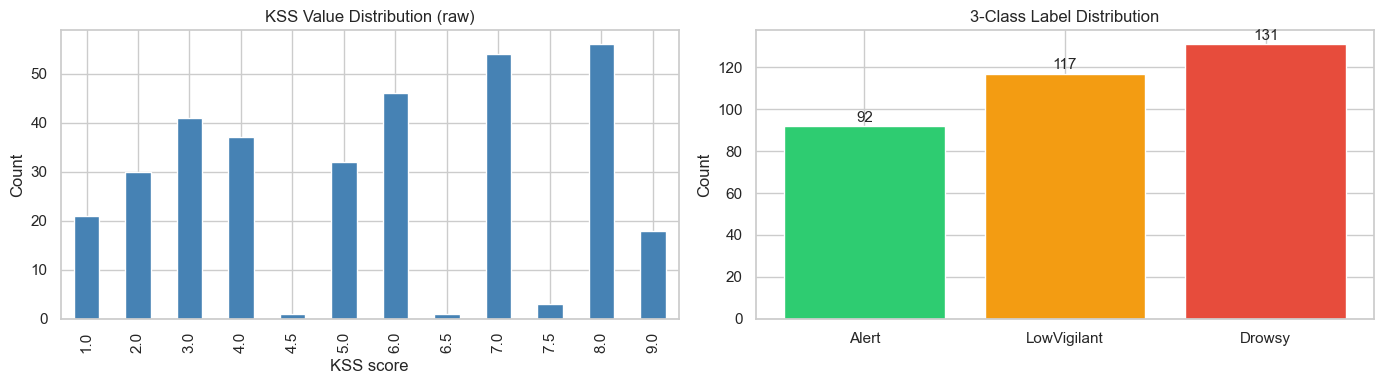

In [4]:
# ── KSS value distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# raw KSS histogram
kss_df['kss'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('KSS Value Distribution (raw)')
axes[0].set_xlabel('KSS score')
axes[0].set_ylabel('Count')

# mapped class distribution
class_counts = kss_df['class'].value_counts().sort_index()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[1].bar(CLASS_NAMES, class_counts.values, color=colors, edgecolor='white')
for bar, cnt in zip(bars, class_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(cnt), ha='center', va='bottom', fontsize=11)
axes[1].set_title('3-Class Label Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(ROOT / 'results/reports/kss_distribution.png', dpi=150)
plt.show()

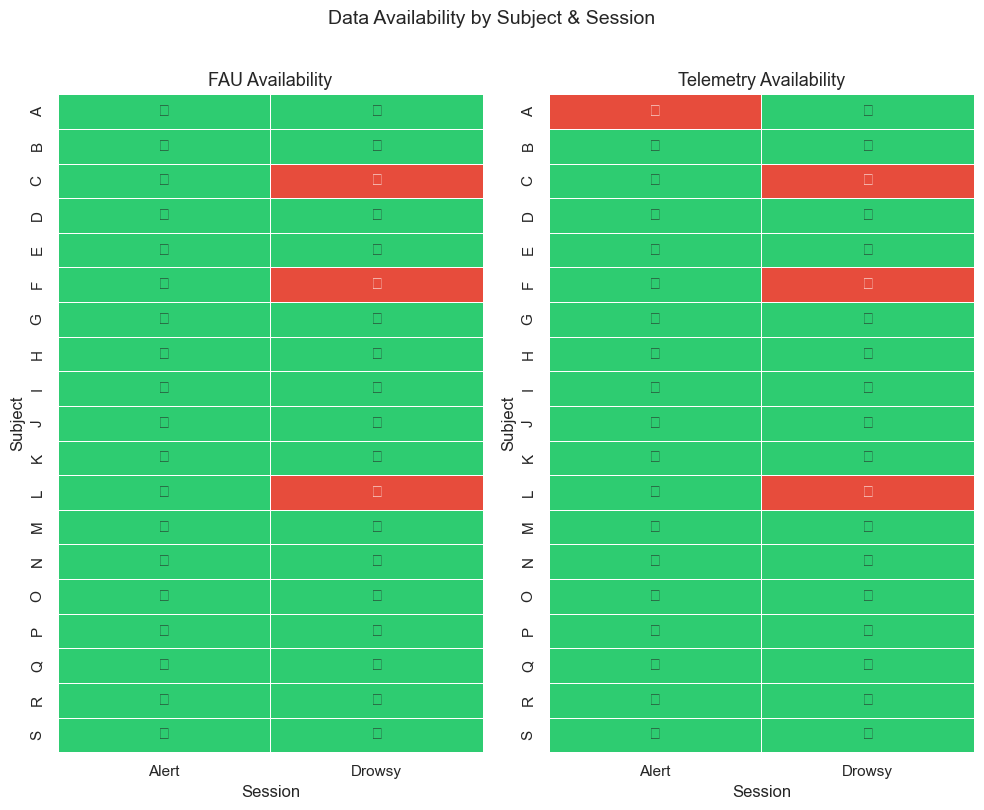

In [5]:
# ── Missing data heatmap ──────────────────────────────────────────────────────
# For each subject × session, check if FAU and Tele CSV exist
rows = []
for s in SUBJECTS:
    for sess in SESSIONS:
        sess_name = 'Alert' if sess == 'A' else 'Drowsy'
        fau_path  = FAU_DIR  / s / sess / f'{s}_FAU_{sess}.csv'
        tele_path = TELE_DIR / s / sess / f'{s}_Telemetry_{sess}.csv'
        rows.append({'Subject': s, 'Session': sess_name,
                     'FAU': int(fau_path.exists()),
                     'Tele': int(tele_path.exists())})

miss_df = pd.DataFrame(rows)
pivot_fau  = miss_df.pivot(index='Subject', columns='Session', values='FAU')
pivot_tele = miss_df.pivot(index='Subject', columns='Session', values='Tele')

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
for ax, data, title in zip(axes, [pivot_fau, pivot_tele], ['FAU Availability', 'Telemetry Availability']):
    sns.heatmap(data.astype(float), ax=ax, cmap=['#e74c3c', '#2ecc71'],
                vmin=0, vmax=1, cbar=False, linewidths=0.5,
                annot=data.map(lambda x: '✓' if x else '✗'), fmt='')
    ax.set_title(title, fontsize=13)

plt.suptitle('Data Availability by Subject & Session', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'results/reports/data_availability.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── Load one FAU file and inspect features ─────────────────────────────────────
sample_subj, sample_sess = 'B', 'A'
fau_path = FAU_DIR / sample_subj / sample_sess / f'{sample_subj}_FAU_{sample_sess}.csv'

fau_df = pd.read_csv(fau_path)
print(f'Shape: {fau_df.shape}')
print(f'Columns: {list(fau_df.columns[:10])} ...')
fau_df.head()

Shape: (144000, 31)
Columns: ['Frame', 'inner_brow_raiser', 'outer_brow_raiser', 'brow_lowerer', 'upper_lid_raiser', 'cheek_raiser_feature', 'lid_tightener', 'nose_wrinkler', 'upper_lip_raiser', 'nasolabial_furrow_deepener'] ...


,Frame,inner_brow_raiser,outer_brow_raiser,brow_lowerer,upper_lid_raiser,cheek_raiser_feature,lid_tightener,nose_wrinkler,upper_lip_raiser,nasolabial_furrow_deepener,...,lips_part,jaw_drop,mouth_stretch,lip_suck,lid_droop,slit,eye_closed,squint,blink,wink
0,1,-1.589543,-1.662168,10.810323,3.081139,30.576894,3.081139,22.022716,6.0,6.082763,...,8.062258,13.0,8.062258,8.062258,2.828427,3.000000,3.081139,10.0,3.081139,3.081139
1,2,-1.589543,-1.912168,11.291047,3.081139,30.467553,3.081139,22.022716,6.0,6.000000,...,8.062258,13.0,8.062258,8.062258,2.828427,3.000000,3.081139,10.0,3.081139,3.081139
2,3,-2.339543,-2.162168,10.689189,3.081139,29.848702,3.162278,22.022716,7.0,6.000000,...,8.000000,13.0,8.000000,8.000000,2.236068,3.162278,3.000000,10.0,3.000000,3.000000
3,4,-2.339543,-2.162168,10.689189,3.081139,29.848702,3.162278,22.022716,7.0,6.000000,...,8.000000,13.0,8.000000,8.000000,2.236068,3.162278,3.000000,10.0,3.000000,3.000000
4,5,-2.339543,-2.162168,10.689189,3.081139,29.848702,3.162278,22.022716,7.0,6.000000,...,8.000000,13.0,8.000000,8.000000,2.236068,3.162278,3.000000,10.0,3.000000,3.000000


In [8]:
# ── AU feature statistics ─────────────────────────────────────────────────────
# Pick AU columns (numeric, excluding frame/timestamp)
au_cols = [c for c in fau_df.select_dtypes(include='number').columns if c.lower() != 'frame']
print(f'AU columns ({len(au_cols)}): {au_cols}')

au_data = fau_df[au_cols].dropna()
au_stats = au_data.describe().T
au_stats

AU columns (30): ['inner_brow_raiser', 'outer_brow_raiser', 'brow_lowerer', 'upper_lid_raiser', 'cheek_raiser_feature', 'lid_tightener', 'nose_wrinkler', 'upper_lip_raiser', 'nasolabial_furrow_deepener', 'lip_corner_puller', 'cheek_puffer', 'dimpler', 'lip_corner_depressor', 'lower_lip_depressor', 'chin_raiser', 'lip_puckerer', 'lip_stretcher', 'lip_funneler', 'lip_tightener', 'lip_pressor', 'lips_part', 'jaw_drop', 'mouth_stretch', 'lip_suck', 'lid_droop', 'slit', 'eye_closed', 'squint', 'blink', 'wink']


,count,mean,std,min,25%,50%,75%,max
inner_brow_raiser,144000.0,-4.042199e-16,3.757291e+00,-11.089543,-2.839543,-1.589543,3.410457,17.660457
outer_brow_raiser,144000.0,-2.627429e-15,3.526593e+00,-9.912168,-2.662168,-1.412168,3.337832,15.587832
brow_lowerer,144000.0,1.084248e+01,3.928332e-01,7.651153,10.689189,10.799897,11.181782,13.500879
upper_lid_raiser,144000.0,3.191177e+00,4.444168e-01,1.000000,3.000000,3.081139,3.500000,5.074265
cheek_raiser_feature,144000.0,3.015669e+01,9.557558e-01,27.192442,29.419380,30.002500,30.927096,39.623620
lid_tightener,144000.0,3.173149e+00,4.825302e-01,1.000000,3.000000,3.081139,3.500000,5.099020
nose_wrinkler,144000.0,2.175576e+01,8.092966e-01,19.104973,21.023796,22.000000,22.090722,29.068884
upper_lip_raiser,144000.0,5.821975e+00,4.817029e-01,4.000000,6.000000,6.000000,6.000000,10.049876
nasolabial_furrow_deepener,144000.0,6.027777e+00,3.940877e-01,5.000000,6.000000,6.000000,6.082763,9.000000
lip_corner_puller,144000.0,1.981583e+01,8.535100e-01,15.000000,19.026298,20.000000,20.024984,32.140317


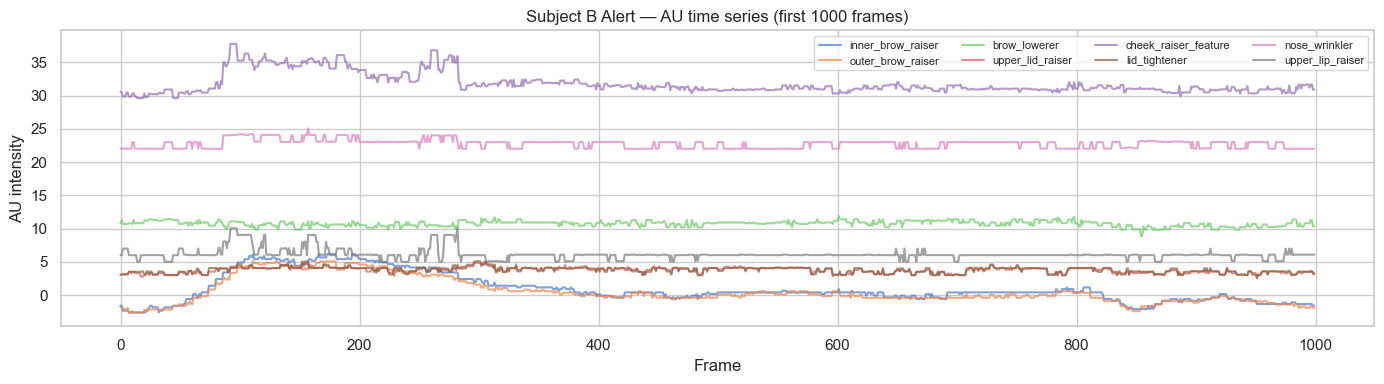

In [9]:
# ── AU mean over time (first 1000 frames ~ 16.7 s) ────────────────────────────
n_plot = min(1000, len(au_data))
fig, ax = plt.subplots(figsize=(14, 4))
for col in au_cols[:8]:   # show first 8 AUs
    ax.plot(au_data[col].values[:n_plot], alpha=0.7, label=col)
ax.set_title(f'Subject {sample_subj} Alert — AU time series (first {n_plot} frames)')
ax.set_xlabel('Frame')
ax.set_ylabel('AU intensity')
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

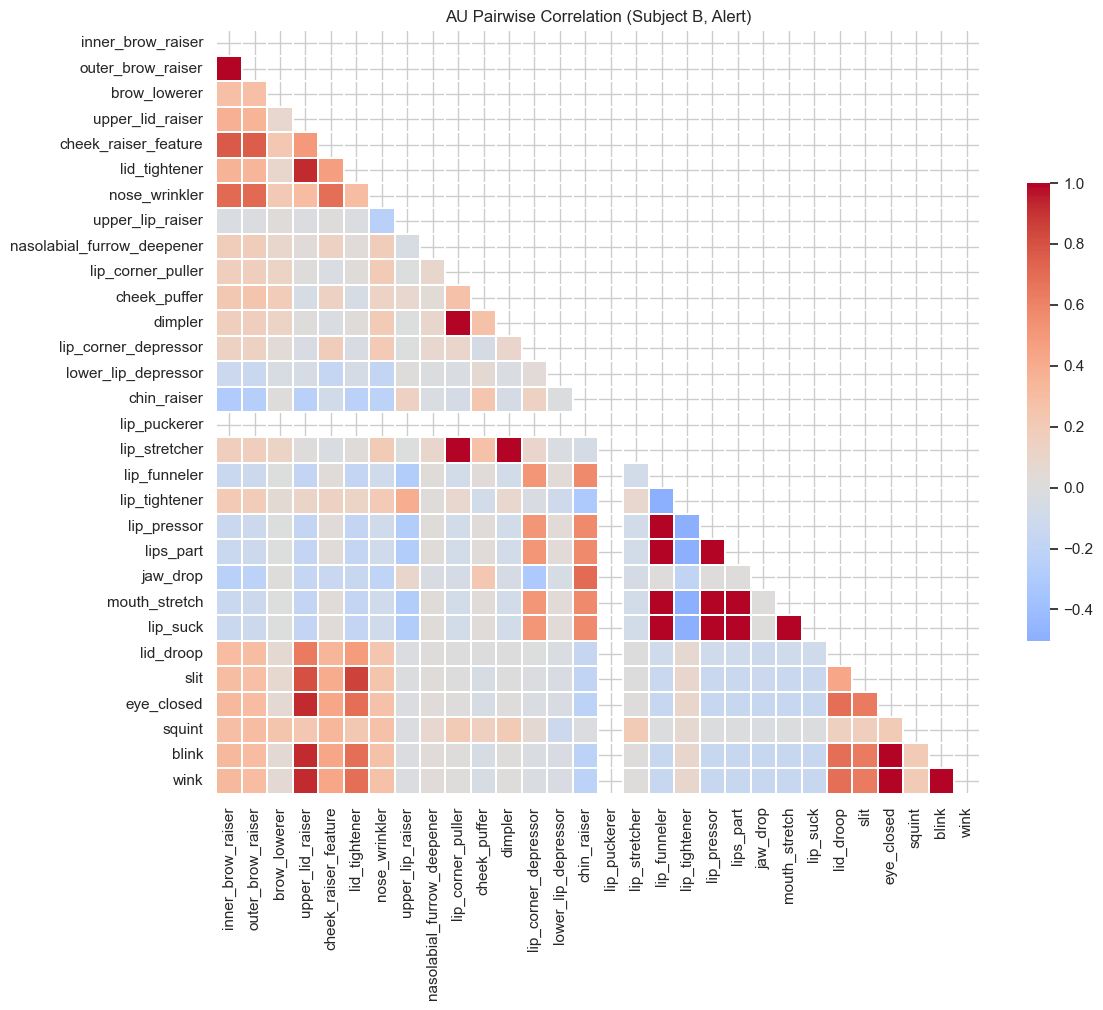

In [10]:
# ── AU pairwise correlation ────────────────────────────────────────────────────
if len(au_cols) >= 2:
    corr = au_data[au_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, ax=ax,
                xticklabels=au_cols, yticklabels=au_cols,
                square=True, linewidths=0.3, cbar_kws={'shrink': .6})
    ax.set_title('AU Pairwise Correlation (Subject B, Alert)')
    plt.tight_layout()
    plt.savefig(ROOT / 'results/reports/au_correlation.png', dpi=150)
    plt.show()

In [11]:
# ── Load one Telemetry file ────────────────────────────────────────────────────
tele_path = TELE_DIR / sample_subj / sample_sess / f'{sample_subj}_Telemetry_{sample_sess}.csv'
tele_df   = pd.read_csv(tele_path)
print(f'Shape: {tele_df.shape}')
print(f'Columns: {list(tele_df.columns)}')
tele_df.head()

Shape: (144000, 10)
Columns: ['timestamp[us]', 'raw rendering timestamp[us]', 'raw simulation timestamp[us]', 'raw paused simulation timestamp[us]', 'heading[deg]', 'pitch[deg]', 'roll[deg]', 'speed[m/s]', 'rpm', 'gear']


,timestamp[us],raw rendering timestamp[us],raw simulation timestamp[us],raw paused simulation timestamp[us],heading[deg],pitch[deg],roll[deg],speed[m/s],rpm,gear
0,64014106,121657746.0,121695132.0,64014106.0,231.151871,0.108245,0.137751,6.539225,1067.348267,8.0
1,64030772,121657746.0,121711798.0,64030772.0,231.058121,0.106209,0.137027,6.544270,1056.450684,8.0
2,64047438,121701894.0,121728464.0,64047438.0,230.965515,0.104147,0.138065,6.549168,1043.176392,8.0
3,64064104,121701894.0,121745130.0,64064104.0,230.873932,0.102070,0.138735,6.553844,1028.265137,8.0
4,64080770,121701894.0,121761796.0,64080770.0,230.783234,0.100035,0.138817,6.558414,1012.507874,8.0


Found telemetry columns: ['pitch[deg]', 'roll[deg]', 'speed[m/s]', 'rpm', 'gear']


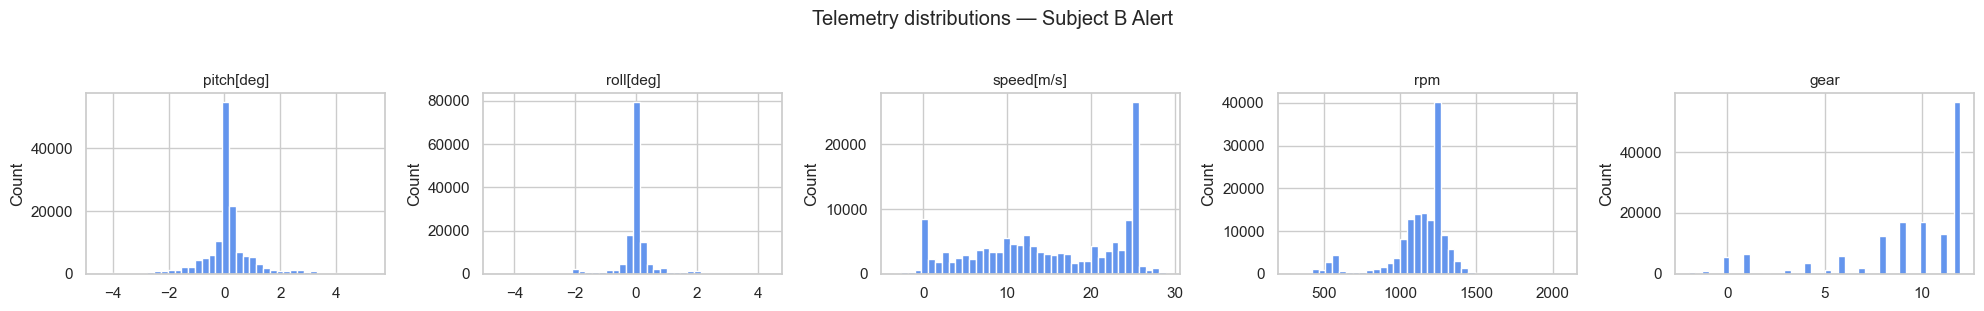

In [12]:
# ── Telemetry feature distributions ──────────────────────────────────────────
TELE_COLS = ['pitch[deg]', 'roll[deg]', 'speed[m/s]', 'rpm', 'gear']
tele_cols_found = [c for c in TELE_COLS if c in tele_df.columns]
print('Found telemetry columns:', tele_cols_found)

if tele_cols_found:
    fig, axes = plt.subplots(1, len(tele_cols_found), figsize=(4*len(tele_cols_found), 3))
    if len(tele_cols_found) == 1: axes = [axes]
    for ax, col in zip(axes, tele_cols_found):
        ax.hist(tele_df[col].dropna(), bins=40, color='cornflowerblue', edgecolor='white')
        ax.set_title(col, fontsize=11)
        ax.set_ylabel('Count')
    plt.suptitle(f'Telemetry distributions — Subject {sample_subj} Alert', y=1.03)
    plt.tight_layout()
    plt.savefig(ROOT / 'results/reports/telemetry_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

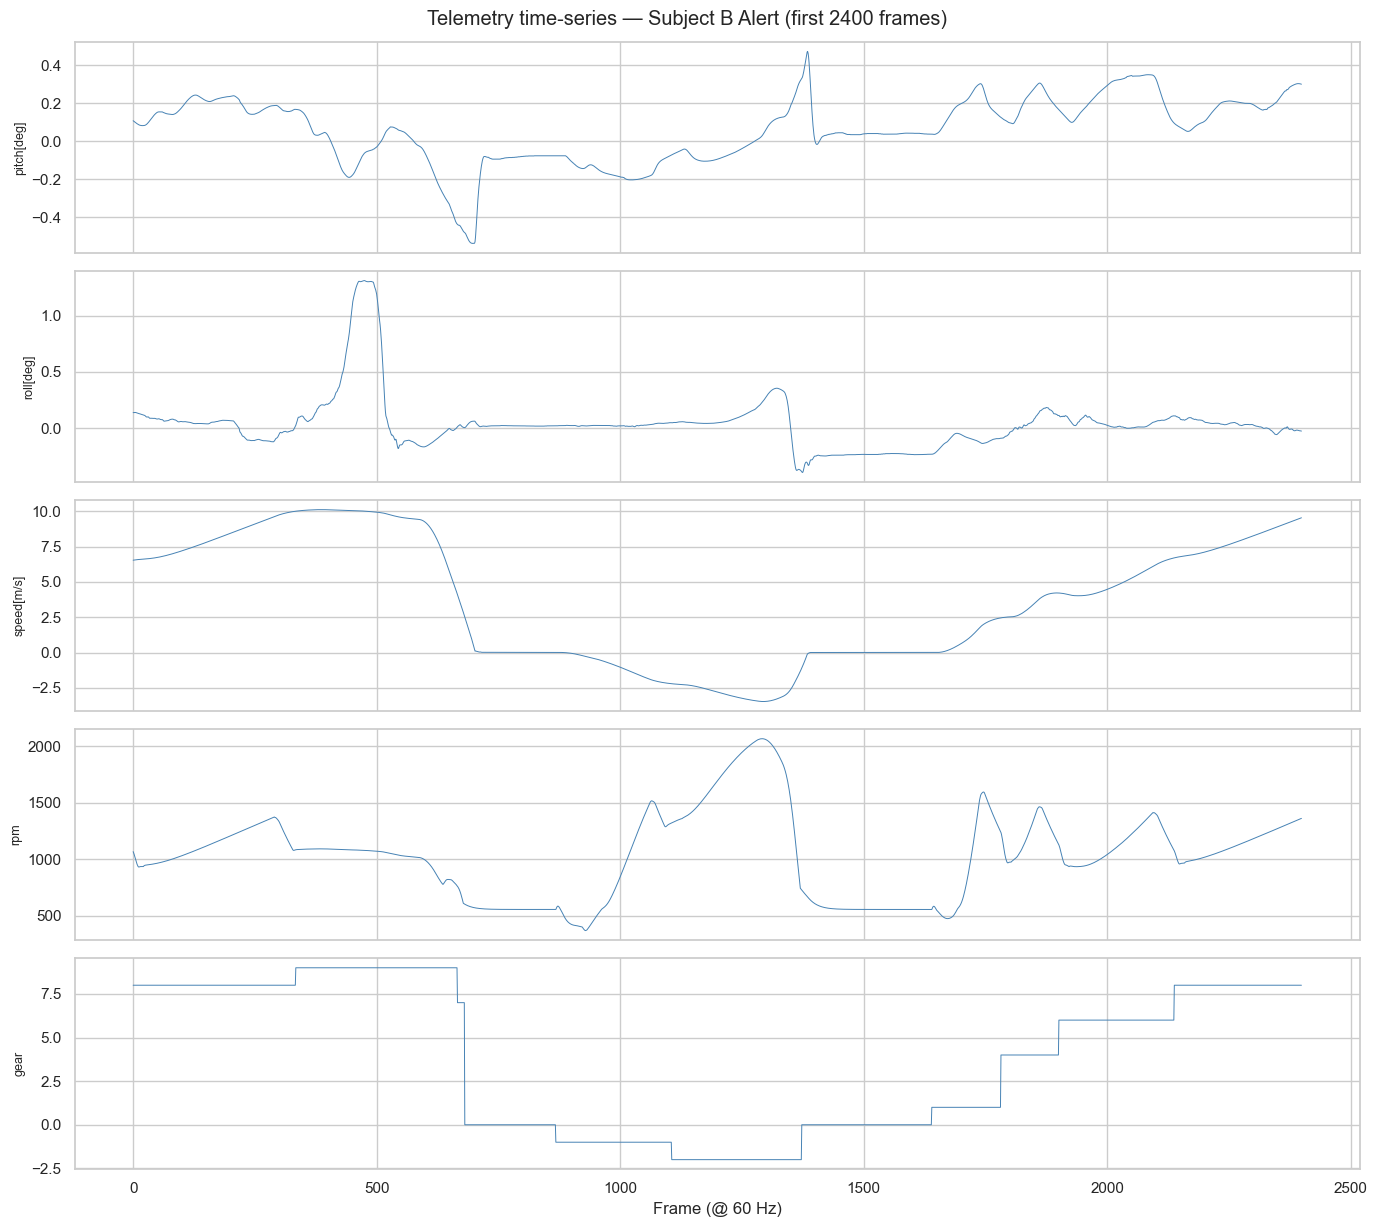

In [13]:
# ── Telemetry time series ─────────────────────────────────────────────────────
n_plot = min(2400, len(tele_df))   # 40 s at 60 Hz
if tele_cols_found:
    fig, axes = plt.subplots(len(tele_cols_found), 1,
                             figsize=(14, 2.5*len(tele_cols_found)), sharex=True)
    if len(tele_cols_found) == 1: axes = [axes]
    for ax, col in zip(axes, tele_cols_found):
        ax.plot(tele_df[col].values[:n_plot], color='steelblue', lw=0.7)
        ax.set_ylabel(col, fontsize=9)
    axes[-1].set_xlabel('Frame (@ 60 Hz)')
    plt.suptitle(f'Telemetry time-series — Subject {sample_subj} Alert (first {n_plot} frames)')
    plt.tight_layout()
    plt.show()

In [14]:
# ── Summary statistics table ──────────────────────────────────────────────────
print('=== Dataset Summary ===')
print(f'Subjects           : {len(SUBJECTS)}')
print(f'Sessions per subj  : 2 (Alert, Drowsy)')
print(f'Duration per sess  : ~40 min @ 60 Hz')
print(f'KSS annotations    : {len(kss_df)}')
print(f'AU features        : {len(au_cols)}')
print(f'Telemetry features : {len(tele_cols_found)}')
print()
print('Class distribution (KSS annotations):')
print(kss_df['class'].value_counts().rename(index={0:'Alert',1:'LowVigilant',2:'Drowsy'}))

=== Dataset Summary ===
Subjects           : 19
Sessions per subj  : 2 (Alert, Drowsy)
Duration per sess  : ~40 min @ 60 Hz
KSS annotations    : 340
AU features        : 30
Telemetry features : 5

Class distribution (KSS annotations):
class
Drowsy         131
LowVigilant    117
Alert           92
Name: count, dtype: int64
